PREPARING DATA

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

# Load the dataset
print("Loading dataset...")
df = pd.read_parquet('../data/final/train_hospital_A_optimized.parquet')

# Separate the features (x) and labels (y) and grouping by Patient_ID to avoid data leakage
groups = df['Patient_ID']
x = df.drop(columns=['Patient_ID', 'SepsisLabel'])
y = df['SepsisLabel']

# Grouped Train/Validation Split
print("Splitting data by Patient_ID...")
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(x, y, groups=groups))

x_train, y_train = x.iloc[train_idx], y.iloc[train_idx]
x_val, y_val = x.iloc[val_idx], y.iloc[val_idx]

# Handle class imbalance by calculating scale_weight
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_weight = neg_class_count / pos_class_count

print("\n ------------ Class Distribution (Train Set) ------------")
print(f"Negative Class Count (0): {neg_class_count}")
print(f"Positive Class Count (1): {pos_class_count}")
print(f"Sepsis Percentage: {(pos_class_count / len(y_train)):.2%}")
print(f"Scale Weight: {scale_weight:.2f}")

Loading dataset...
Splitting data by Patient_ID...

 ------------ Class Distribution (Train Set) ------------
Negative Class Count (0): 617388
Positive Class Count (1): 8592
Sepsis Percentage: 1.37%
Scale Weight: 71.86


INITIALIZING AND TRAINING THE MODEL

In [2]:
print("Training XGBoost classifier...")

# Initilizing the model
clf = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_weight,
    objective='binary:logistic',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    tree_method='hist',
    device='cuda'
)

# Training the model
clf.fit(
    x_train, y_train,
    eval_set=[(x_val, y_val)],
    verbose=100
)

Training XGBoost classifier...
[0]	validation_0-aucpr:0.04688
[85]	validation_0-aucpr:0.05133


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'aucpr'


EVALUATION

In [3]:
print("\nEvaluating model...")

clf.set_params(device='cpu')

# Extract probabilities for positive class
y_pred_proba = clf.predict_proba(x_val)[:, 1]

auroc = roc_auc_score(y_val, y_pred_proba)
pr_auc = average_precision_score(y_val, y_pred_proba)

print("\n--- Final Validation Metrics ---")
print(f"AUROC: {auroc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")


Evaluating model...

--- Final Validation Metrics ---
AUROC: 0.7830
PR AUC: 0.0543


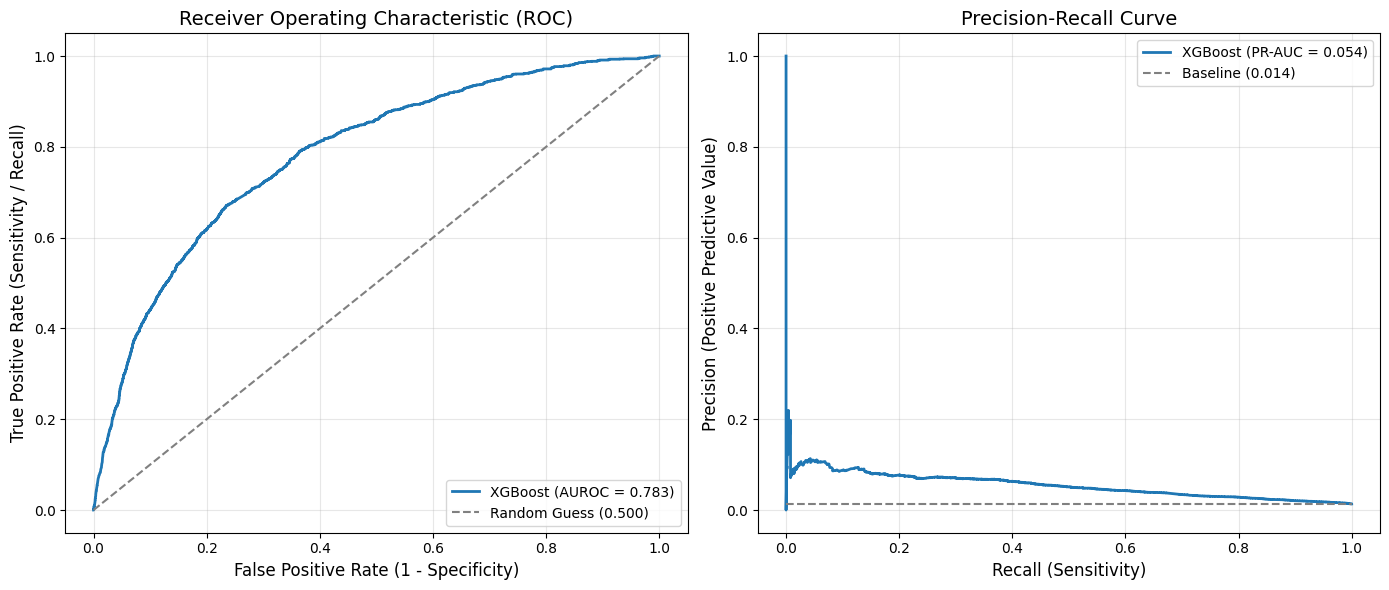

In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# Calculate the curves
fpr, tpr, roc_thresholds = roc_curve(y_val, y_pred_proba)
precision, recall, pr_thresholds = precision_recall_curve(y_val, y_pred_proba)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: ROC Curve ---
ax1.plot(fpr, tpr, label=f'XGBoost (AUROC = {auroc:.3f})', linewidth=2)
ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (0.500)')
ax1.set_title('Receiver Operating Characteristic (ROC)', fontsize=14)
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax1.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# --- Plot 2: Precision-Recall Curve ---
ax2.plot(recall, precision, label=f'XGBoost (PR-AUC = {pr_auc:.3f})', linewidth=2)

# Calculate the baseline for PR Curve
baseline_pr = (y_val == 1).sum() / len(y_val)
ax2.plot([0, 1], [baseline_pr, baseline_pr], linestyle='--', color='gray', 
         label=f'Baseline ({baseline_pr:.3f})')

ax2.set_title('Precision-Recall Curve', fontsize=14)
ax2.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax2.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE VISUALIZATION


Generating feature importance plot...


<Figure size 1500x800 with 0 Axes>

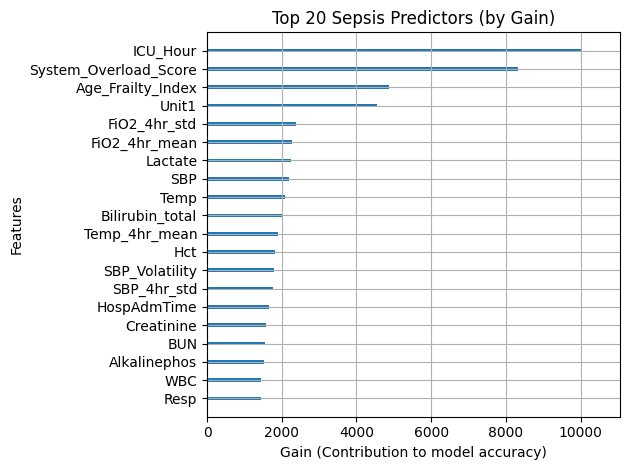

In [5]:
print("\nGenerating feature importance plot...")

plt.figure(figsize=(15, 8))
xgb.plot_importance(
    clf,
    max_num_features=20,
    importance_type='gain',
    show_values=False,
    title='Top 20 Sepsis Predictors (by Gain)',
    xlabel='Gain (Contribution to model accuracy)',
    ylabel='Features'
)

plt.tight_layout()
plt.show()

OPTIMAL THRESHOLD

In [6]:
# Calculate F2-scores for every single threshold tested by the PR Curve
# We add a tiny number (1e-10) to the denominator to prevent division-by-zero errors
# The beta parameter dictates the weight of Recall. Beta=2 means Recall is 2x more important.
beta = 2
f2_scores = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall + 1e-10)

# Find the index of the highest F2-Score
best_idx = np.argmax(f2_scores)

# 3. Extract the exact metrics at that specific index
best_threshold = pr_thresholds[best_idx]
best_f2 = f2_scores[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]

# 4. Print the clinical translation
print("\n--- Optimal Clinical Threshold ---")
print(f"Optimal Probability Threshold: {best_threshold:.4f} ({best_threshold*100:.1f}%)")
print(f"Max F2-Score: {best_f2:.4f}")
print(f"Precision at this threshold: {best_precision:.4f} (When the alarm sounds, it is correct {best_precision*100:.1f}% of the time)")
print(f"Recall at this threshold:    {best_recall:.4f} (The alarm catches {best_recall*100:.1f}% of all actual Sepsis cases)")


--- Optimal Clinical Threshold ---
Optimal Probability Threshold: 0.6059 (60.6%)
Max F2-Score: 0.1961
Precision at this threshold: 0.0675 (When the alarm sounds, it is correct 6.8% of the time)
Recall at this threshold:    0.3743 (The alarm catches 37.4% of all actual Sepsis cases)


IMPORTANT BASELINE METRICS:
- PR-AUC = 0.054
- MAX F-2 SCORE = 0.1961
- RECALL = 37.4%

ERROR ANALYSIS

Extracting Native SHAP Values...
Generating Global SHAP Summary Plot...


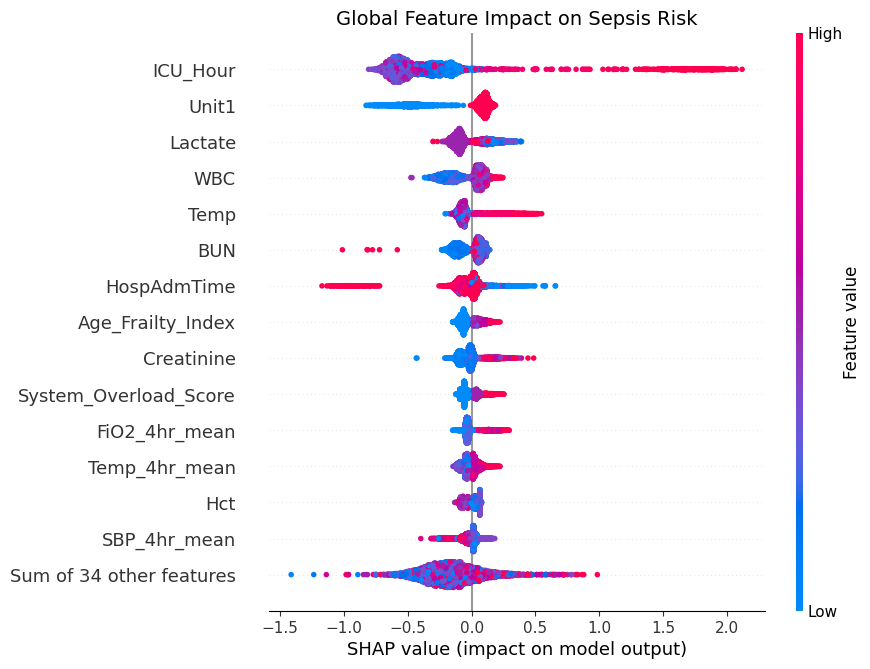


Hunting for the worstFalse Negative (Missed Sepsis Case)...

Autopsy for Patient Index: 505149
Actual Label: 1 (Sepsis)
Model Predicted Risk: 19.78%


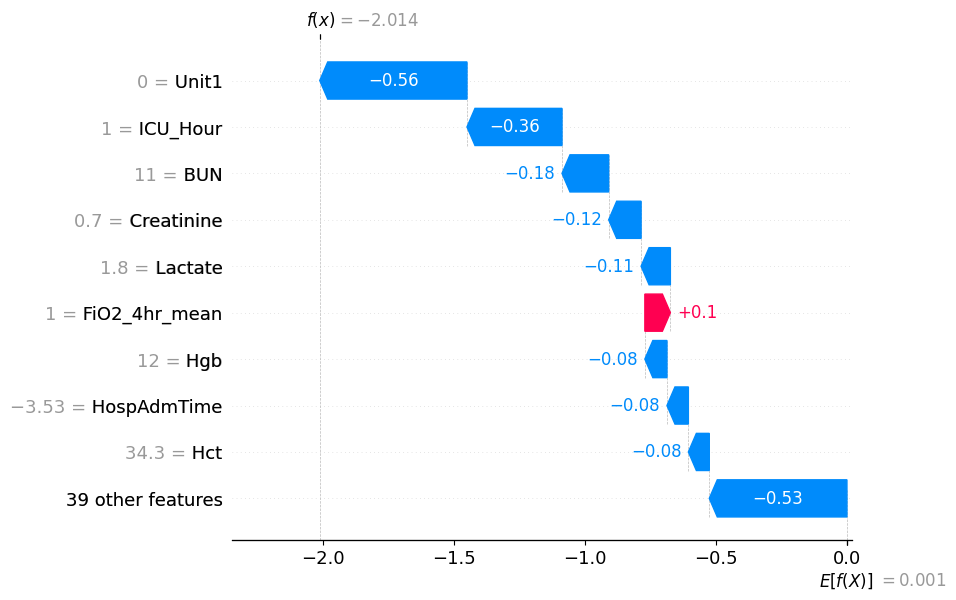

In [7]:
import shap

print("Extracting Native SHAP Values...")

# We use XGBoost's built-in C++ SHAP calculator (pred_contribs=True)
booster = clf.get_booster()

x_val_sample = x_val.sample(n=5000, random_state=42)
dmatrix_sample = xgb.DMatrix(x_val_sample)

# This returns a matrix where the very last column is the base_score (bias)
shap_contribs_sample = booster.predict(dmatrix_sample, pred_contribs=True)

# Package it into a SHAP Explanation object
shap_values_sample = shap.Explanation(
    values=shap_contribs_sample[:, :-1],       # All columns except the last
    base_values=shap_contribs_sample[:, -1],   # Only the last column
    data=x_val_sample, 
    feature_names=x_val_sample.columns.tolist()
)

# --- GLOBAL ANALYSIS ---
print("Generating Global SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
plt.title("Global Feature Impact on Sepsis Risk", fontsize=14)
shap.plots.beeswarm(shap_values_sample, max_display=15)
plt.show()

# --- ERROR ANALYSIS (Autopsy) ---
print("\nHunting for the worstFalse Negative (Missed Sepsis Case)...")

# Filter to ONLY patients who actually got Sepsis
sepsis_patients_mask = (y_val == 1)
sepsis_indices = x_val[sepsis_patients_mask].index

# Find the patient in that group with the absolute lowest predicted risk
worst_miss_idx = sepsis_indices[np.argmin(y_pred_proba[sepsis_patients_mask])]
missed_patient_data = x_val.loc[[worst_miss_idx]]

# Calculate native SHAP for this specific patient
dmatrix_patient = xgb.DMatrix(missed_patient_data)
patient_contribs = booster.predict(dmatrix_patient, pred_contribs=True)

shap_values_patient = shap.Explanation(
    values=patient_contribs[0, :-1], 
    base_values=patient_contribs[0, -1],
    data=missed_patient_data.iloc[0], 
    feature_names=missed_patient_data.columns.tolist()
)

print(f"\nAutopsy for Patient Index: {worst_miss_idx}")
print("Actual Label: 1 (Sepsis)")
patient_risk = clf.predict_proba(missed_patient_data)[:, 1][0]
print(f"Model Predicted Risk: {patient_risk * 100:.2f}%")

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values_patient) 
plt.show()